<a href="https://colab.research.google.com/github/2303A51132/51132/blob/main/Parallel_Calculation_of_Fibonacci_Numbers_For_Fraud_Detection_in_Banking_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Generation

In [3]:
import pandas as pd
import random
data = []
for i in range(1200):
    amount = random.randint(100, 20000)
    transaction_type = random.choice(["Online", "ATM", "POS", "Transfer"])
    time_hour = random.randint(0, 23)
    # Fraud logic
    if amount > 15000 or (transaction_type == "Online" and time_hour > 22):
        fraud = 1
    else:
        fraud = 0
    data.append([i+1, amount, transaction_type, time_hour, fraud])
df = pd.DataFrame(data, columns=[
    "Transaction_ID", "Amount", "Transaction_Type", "Time_Hour", "Fraud"
])
print(df.head())

   Transaction_ID  Amount Transaction_Type  Time_Hour  Fraud
0               1   19020         Transfer         10      1
1               2    9990         Transfer         14      0
2               3   10912              POS         18      0
3               4   19218              ATM          9      1
4               5   17333         Transfer         15      1


Fibonacci Function

In [5]:
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

Serial Implementation

In [7]:
import time
start = time.time()
serial_results = []
for i in range(len(df)):
    serial_results.append(fib(18))
serial_time = time.time() - start
print("Serial Time:", serial_time)

Serial Time: 0.6009595394134521


Parallel Implementation (Multiprocessing)

In [9]:
import multiprocessing
import time # Added import time

def parallel_task(x):
    return fib(18)

if __name__ == "__main__": # Corrected __name__ and __main__
    start = time.time()
    pool = multiprocessing.Pool()
    parallel_results = pool.map(parallel_task, range(len(df)))
    pool.close()
    pool.join()
    parallel_time = time.time() - start
    print("Parallel Time:", parallel_time)

Parallel Time: 0.9612460136413574


Performance Calculation

In [11]:
speedup = serial_time / parallel_time
print("Speedup:", speedup)

Speedup: 0.6251880693236053


Visualization (Graphs)

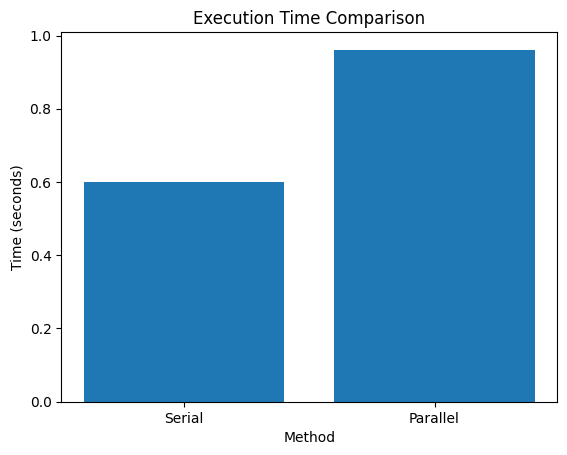

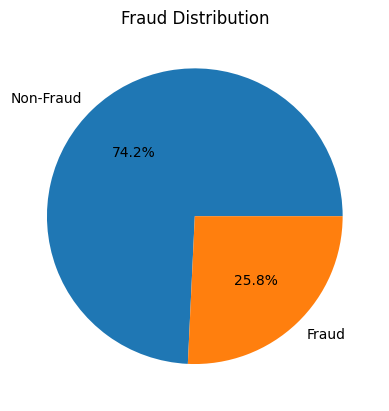

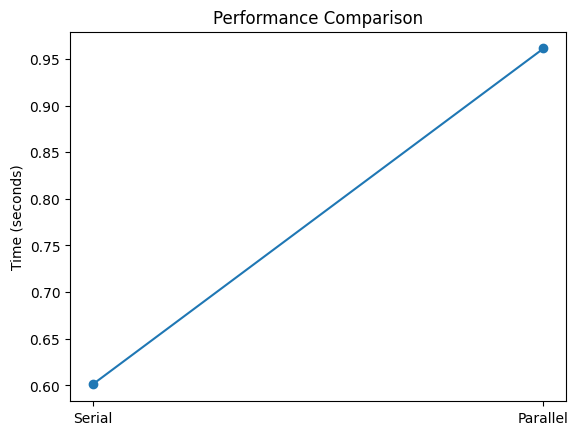

In [13]:
import matplotlib.pyplot as plt
# Bar Graph
plt.figure()
plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])
plt.title("Execution Time Comparison")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")
plt.show()
# Pie Chart
fraud_counts = df["Fraud"].value_counts()
plt.figure()
plt.pie(fraud_counts, labels=["Non-Fraud", "Fraud"], autopct='%1.1f%%')
plt.title("Fraud Distribution")
plt.show()
# Line Graph
plt.figure()
plt.plot([serial_time, parallel_time], marker='o')
plt.xticks([0, 1], ["Serial", "Parallel"])
plt.title("Performance Comparison")
plt.ylabel("Time (seconds)")
plt.show()